# 3.0 Experimento principal

Este notebook es el esqueleto del experimento final. La idea es ejecutarlo en una
máquina con más recursos, por ejemplo Google Colab, sin mezclarlo con los notebooks
exploratorios anteriores.

Ruta final:

1. cargar muestra simulada GUMS/GOG con verdad conocida;
2. preparar variables observadas y cortes de calidad;
3. construir grilla fija del CMD independiente de la muestra de evaluación;
4. ajustar Modelo 0 (solo paralaje, prior uniforme truncado);
5. ajustar Modelo 1 (CMD marginalizado, pesos flexibles);
6. ajustar Modelo 2 (CMD marginalizado + escala global lambda);
7. validar VI con métricas contra verdad simulada y NUTS en submuestra;
8. guardar trazas ArviZ y tablas listas para el Capítulo IV.

## Instalación en Colab

In [ ]:
!pip install -q "project[colab] @ git+https://github.com/IsaacMercado/estimacion-paralajes.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.9 MB/s eta 0:00:00


In [ ]:
from dataclasses import asdict
from pathlib import Path

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import polars as pl
import scipy.stats as stats
import seaborn as sns
import sympy as sp
from jax import random
from jax.scipy.special import logsumexp
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoLowRankMultivariateNormal
from numpyro.optim import Adam

from project.utils import DATA_RAW_DIR, MODELS_DIR
from project.utils.load import load_with_polars
from project.validation import evaluate_distance_posterior, summarize_elbo

jax.config.update("jax_enable_x64", True)

print('Devices:', jax.devices())
print('Backend:', jax.default_backend())
print("Count Devices:", jax.local_device_count())

Devices: [CudaDevice(id=0)]
Backend: gpu


In [ ]:
SIMULATION_FILENAME = "simulation_data.ecsv"
FITZ19_FILENAME = "Fitz19_EDR3_MainSequence.csv"
SIMULATION_FILE = DATA_RAW_DIR / SIMULATION_FILENAME
FITZ19_FILE = DATA_RAW_DIR / FITZ19_FILENAME
SEED = 2026

In [ ]:
try:
  from google.colab import drive
  import shutil

  path_drive = Path("/content/drive")
  drive.mount(path_drive.as_posix())

  path_simulation_file = path_drive / "MyDrive" / SIMULATION_FILENAME
  if not path_simulation_file.exists():
      raise FileNotFoundError(f"File {path_simulation_file} not found.")

  shutil.copyfile(path_simulation_file, SIMULATION_FILE)

  path_fitz19_file = path_drive / "MyDrive" / FITZ19_FILENAME
  if not path_fitz19_file.exists():
      raise FileNotFoundError(f"File {path_fitz19_file} not found.")

  shutil.copyfile(path_fitz19_file, FITZ19_FILE)

except NotImplementedError:
    !pip install -q gdown
    !gdown "https://drive.google.com/uc?id=1tQk1hUPhQ3VPfo-PXQD-_ZVUiF_vPMh9" -O $SIMULATION_FILE
    !gdown "https://drive.google.com/uc?id=1XkUmmr1F8oKABP1Eou3lbC4jCsWEpkum" -O $FITZ19_FILE

except ModuleNotFoundError:
  print("Not running in Colab.")

Mounted at /content/drive


## Preparación de datos

Reemplazar esta función con la lectura final de la muestra simulada. Es importante
guardar y conservar `source_id` para verificar que la traza y la tabla estén en el
mismo orden.

### Fórmulas de extinción estelar

In [ ]:
teff, teff_error, a0, a0_error, *a = sp.symbols(
    'teff teff_error '
    'A0 A0_error '
    'a1 a2 a3 a4 a5 a6 a7 a8 a9 a10'
)
X = teff / 5040
k_m = (
    a[0] +
    a[1]*X +
    a[2]*X**2 +
    a[3]*X**3 +
    a[4]*a0 +
    a[5]*a0**2 +
    a[6]*a0**3 +
    a[7]*a0*X +
    a[8]*a0*X**2 +
    a[9]*X*a0**2
)
A_m = k_m * a0
k_m_error = sp.sqrt(
    (sp.diff(A_m, teff)*teff_error)**2 +
    (sp.diff(A_m, a0)*a0_error)**2
)


def extinction_m(coeff: pl.DataFrame, color: str):
  k_m_name = f"k{color.upper()}"

  values = (
      coeff.filter(pl.col("Kname") == k_m_name)
      .select(pl.all().exclude("Kname"))
  ).row(0)

  expr_km = sp.lambdify((teff, a0, *a), k_m)(
      pl.col("teff"),
      pl.col("a0"),
      *values,
  )
  expr_am_error = sp.lambdify((teff, a0, teff_error, a0_error, *a), k_m_error)(
      pl.col("teff"),
      pl.col("a0"),
      pl.col("teff_error") ,
      pl.col("a0_error"),
      *values
  )

  return (
      (pl.col("a0")*expr_km).alias(f"a{color.lower()}"),
      expr_am_error.alias(f"a{color.lower()}_error")
  )

### Lectura de datos

In [ ]:
def flux_to_mag_sigma(flux_col: str, flux_error_col: str) -> pl.Expr:
    snr = pl.col(flux_col) / pl.col(flux_error_col)
    return (2.5 / np.log(10.0) / snr).cast(pl.Float32)


def load_simulated_catalog(path: Path) -> pl.DataFrame:
    df, _columns = load_with_polars(path)
    return (
        df
        .drop_nans()
        .drop_nulls()
        .with_columns(
            (pl.col("parallax") / pl.col("parallax_error")).alias("parallax_snr"),
            (pl.col("phot_bp_mean_mag") - pl.col("phot_rp_mean_mag")).alias("color_obs"),
        )
        .with_columns(
            flux_to_mag_sigma("phot_g_mean_flux", "phot_g_mean_flux_error").alias("sigma_g_mag"),
            flux_to_mag_sigma("phot_bp_mean_flux", "phot_bp_mean_flux_error").alias("sigma_bp_mag"),
            flux_to_mag_sigma("phot_rp_mean_flux", "phot_rp_mean_flux_error").alias("sigma_rp_mag"),
        )
        .with_columns(
            (
                (pl.col("sigma_bp_mag").pow(2) + pl.col("sigma_rp_mag").pow(2))
                .sqrt()
                .alias("sigma_color")
            ),
            pl.col("parallax_snr").cut(
                breaks=[3, 5, 10],
                labels=["1-3", "3-5", "5-10", ">10"]
            ).alias("stratum"),
        )
    )


def select_simulation_sample(df: pl.DataFrame, n_stars: int, seed: int) -> pd.DataFrame:
    if df.height > n_stars:
        df = df.sample(n=n_stars, seed=seed)
    return df.sort("source_id")


def load_fitz19_catalog(path: Path) -> pl.DataFrame:
    return (
        pl.read_csv(path)
        .filter(pl.col("Xname") == "TeffNorm")
        .filter(pl.col("Kname").is_in(("kRP", "kBP", "kG")))
        .select(pl.all().exclude("Xname"))
    )

In [ ]:
coeff = load_fitz19_catalog(DATA_RAW_DIR / FITZ19_FILENAME)
catalog = load_simulated_catalog(SIMULATION_FILE).with_columns([
    *extinction_m(coeff, "g"),
    *extinction_m(coeff, "bp"),
    *extinction_m(coeff, "rp"),
])
catalog.head()

source_id,ra,dec,barycentric_distance,mag_g,mag_bp,mag_rp,ra_sim,ra_error,dec_sim,dec_error,parallax,parallax_error,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_mag,teff,teff_error,a0,a0_error,parallax_snr,color_obs,sigma_g_mag,sigma_bp_mag,sigma_rp_mag,sigma_color,stratum,ag,ag_error,abp,abp_error,arp,arp_error
i64,f64,f64,f32,f32,f32,f32,f64,f32,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,enum,f32,f32,f32,f32,f32,f32
1729382514608308297,266.485879,-28.924615,5703.887207,15.840521,16.262024,15.211703,266.485879,0.052013,-28.924619,0.052781,0.203568,0.075509,8060.158203,6.16043,15.842641,4068.377197,3.397017,16.263247,5856.459473,5.998731,15.210512,10592.537109,0.0,2.415923,0.0,2.69593,1.052734,0.00083,0.000907,0.001112,0.001435,"""1-3""",2.261103,0.0,2.66775,0.0,1.588,0.0
1729382514608309151,266.490112,-28.922073,1327.904663,17.343899,18.074467,16.473137,266.490102,0.106769,-28.922081,0.108343,0.654801,0.154997,135.595551,0.2129,20.277887,28.787418,0.507285,21.638794,1798.994629,47.193829,16.492025,5546.257324,0.0,1.793379,0.0,4.224599,5.146769,0.001705,0.019133,0.028483,0.034312,"""3-5""",1.468504,0.0,1.860162,0.0,1.139602,0.0
1729382514608309157,266.487797,-28.919457,2425.311035,19.013836,19.919689,18.033987,266.487796,0.36829,-28.919457,0.373711,1.062139,0.534636,193.712372,0.254324,19.890606,140.034149,1.87882,19.921215,423.660431,8.362626,18.062056,5559.04248,0.0,2.534543,0.0,1.986659,1.859159,0.001425,0.014567,0.021431,0.025913,"""1-3""",2.034306,0.0,2.603254,0.0,1.599415,0.0
1729382514608310001,266.486195,-28.913284,7530.526855,20.165361,21.177307,19.130116,266.48619,1.514585,-28.913302,1.536785,3.376858,2.198548,149.80603,0.347064,20.169678,45.290649,1.151855,21.146778,152.875778,5.764545,19.168753,5610.47998,0.0,2.924928,0.0,1.535949,1.978025,0.002515,0.027613,0.04094,0.049382,"""1-3""",2.329338,0.0,2.992984,0.0,1.840337,0.0
1729382514608310094,266.488103,-28.916805,7646.353516,18.036472,19.504309,16.818388,266.488095,0.167151,-28.916817,0.169607,0.342175,0.242643,1067.234619,0.896529,18.037849,205.832779,0.625357,19.503014,1328.136963,5.87102,16.821493,4549.880371,0.0,3.869021,0.0,1.4102,2.68152,0.000912,0.003299,0.004799,0.005824,"""1-3""",2.821571,0.0,3.802994,0.0,2.356046,0.0


In [ ]:
catalog.group_by("stratum").agg(
    pl.col("parallax_snr").count().alias("count"),
    pl.col("parallax_snr").mean().alias("mean"),
    pl.col("parallax_snr").std().alias("std"),
    pl.col("parallax_snr").min().alias("min"),
    pl.col("parallax_snr").max().alias("max"),
).sort("stratum")

stratum,count,mean,std,min,max
enum,u32,f32,f32,f32,f32
"""1-3""",1685826,1.737169,0.531606,1.0,2.999998
"""3-5""",351021,3.818312,0.568668,3.000001,4.999993
"""5-10""",260817,6.94566,1.401959,5.000045,9.999958
""">10""",202336,22.732235,22.879391,10.000004,1148.494263


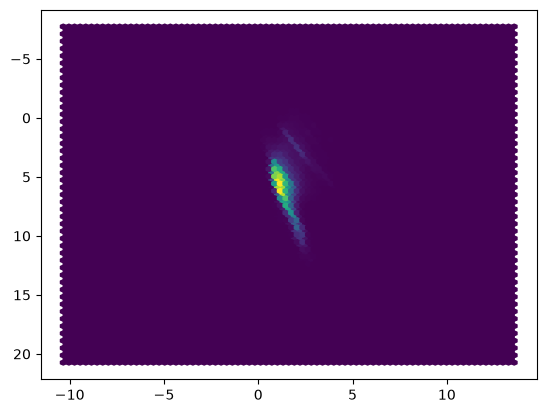

In [ ]:
M_obs = catalog["phot_g_mean_mag"] - 5*np.log10(catalog["barycentric_distance"]) + 5  # ojo unidades pc
plt.hexbin(catalog["color_obs"], M_obs, gridsize=80)
plt.gca().invert_yaxis()

In [ ]:
catalog.select(
    "teff_error",
    "a0_error",
    "ag_error",
    "abp_error",
    "arp_error",
).sum()

teff_error,a0_error,ag_error,abp_error,arp_error
f32,f32,f32,f32,f32
0.0,0.0,0.0,0.0,0.0


## Grilla fija del CMD

No construir esta grilla con cuantiles de la misma muestra evaluada. Aquí se usa un
rango fijo amplio para Gaia. Ajustar resolución según recursos disponibles.

In [ ]:
def compute_oreacle_weights(df: pl.DataFrame, grid: dict) -> np.ndarray:
    # CORRECCIÓN: Eliminamos el * 1e3 porque barycentric_distance ya está en parsecs
    M_G_true, color_true = df.select(
        (pl.col("mag_g") - 5.0 * pl.col("barycentric_distance").log10() + 5.0).alias("M_G_true"),
        (pl.col("mag_bp") - pl.col("mag_rp").alias("color_true")),
    ).to_jax().T

    counts, _, _ = jnp.histogram2d(
        color_true, # El orden en histogram2d es [x, y]
        M_G_true,
        bins=[grid["color_edges"], grid["abs_edges"]],
        density=True
    )
    # Transponemos para que coincida con el ravel() de mu_color/mu_abs_mag
    w_oracle = counts.T.ravel()
    w_oracle = w_oracle / (w_oracle.sum() + 1e-12)
    return w_oracle


def build_fixed_cmd_grid(
    color_range=(-0.5, 9.0),
    abs_mag_range=(-4.0, 16.0),
    n_color=25,
    n_abs_mag=35,
):
    color_edges = np.linspace(color_range[0], color_range[1], n_color + 1)
    mag_edges = np.linspace(abs_mag_range[0], abs_mag_range[1], n_abs_mag + 1)
    color_step = color_edges[1] - color_edges[0]
    mag_step = mag_edges[1] - mag_edges[0]
    color_centers = 0.5 * (color_edges[:-1] + color_edges[1:])
    mag_centers = 0.5 * (mag_edges[:-1] + mag_edges[1:])
    grid_color, grid_mag = np.meshgrid(color_centers, mag_centers, indexing="xy")
    return {
        "mu_color": grid_color.ravel(),
        "mu_abs_mag": grid_mag.ravel(),
        "sigma_color_kernel": np.full(grid_color.size, color_step),
        "sigma_abs_mag_kernel": np.full(grid_color.size, mag_step),
        "color_edges": color_edges,
        "abs_edges": mag_edges,
        "shape": grid_mag.shape,
    }

def prepare_model_data(df: pl.DataFrame, grid: dict, r_min=10.0, r_max=20_000.0) -> dict:
    w_oracle = compute_oreacle_weights(df, grid)
    return {
        "parallax": df["parallax"].to_numpy(),
        "parallax_error": df["parallax_error"].to_numpy(),

        # CORRECCIÓN: Restamos la extinción Ag para obtener la magnitud observada
        "m_obs": df["phot_g_mean_mag"].to_numpy() - df["ag"].to_numpy(),
        # CORRECCIÓN: Ajustamos el color observado para la extinción
        "color_obs": df["color_obs"].to_numpy() - df["abp"].to_numpy() + df["arp"].to_numpy(),

        "sigma_m": df["sigma_g_mag"].to_numpy(),
        "sigma_color": df["sigma_color"].to_numpy(),

        "r_min": float(r_min),
        "r_max": float(r_max),
        "oracle_weights": w_oracle,
        **grid,
    }

## Modelos NumPyro

In [ ]:
def model_0_parallax_only(parallax, parallax_error, r_min, r_max, **_):
    n_stars = parallax.shape[0]
    with numpyro.plate("star", n_stars):
        distance_pc = numpyro.sample("distance_pc", dist.Uniform(r_min, r_max))
        numpyro.sample("parallax_like", dist.Normal(1000.0 / distance_pc, parallax_error), obs=parallax)


def model_1_cmd_marginalized(
    parallax,
    parallax_error,
    m_obs,
    sigma_m,
    color_obs,
    sigma_color,
    r_min,
    r_max,
    mu_abs_mag,
    mu_color,
    sigma_abs_mag_kernel,
    sigma_color_kernel,
    **_,
):
    n_stars = parallax.shape[0]
    n_kernels = mu_abs_mag.shape[0]
    weights = numpyro.sample("weights", dist.Dirichlet(jnp.ones(n_kernels)))

    with numpyro.plate("star", n_stars):
        distance_pc = numpyro.sample("distance_pc", dist.Uniform(r_min, r_max))

    log_parallax = dist.Normal(1000.0 / distance_pc, parallax_error).log_prob(parallax)
    mu_m = mu_abs_mag[None, :] + 5.0 * jnp.log10(distance_pc[:, None]) - 5.0
    sigma_m_total = jnp.sqrt(sigma_m[:, None] ** 2 + sigma_abs_mag_kernel[None, :] ** 2)
    sigma_c_total = jnp.sqrt(sigma_color[:, None] ** 2 + sigma_color_kernel[None, :] ** 2)
    log_cmd = logsumexp(
        jnp.log(weights + 1e-12)[None, :]
        + dist.Normal(mu_m, sigma_m_total).log_prob(m_obs[:, None])
        + dist.Normal(mu_color[None, :], sigma_c_total).log_prob(color_obs[:, None]),
        axis=-1,
    )
    numpyro.factor("obs_loglike", jnp.sum(log_parallax + log_cmd))


def model_2_cmd_lambda(**kwargs):
    lambda_cmd = numpyro.sample("lambda_cmd", dist.LogNormal(0.0, 0.25))
    modified = dict(kwargs)
    modified["sigma_abs_mag_kernel"] = kwargs["sigma_abs_mag_kernel"] * lambda_cmd
    modified["sigma_color_kernel"] = kwargs["sigma_color_kernel"] * lambda_cmd
    return model_1_cmd_marginalized(**modified)

## Ajuste VI

In [ ]:
def run_vi(model, model_data, *, seed, steps=20_000, lr=0.01, rank=25, samples=4_000):
    guide = AutoLowRankMultivariateNormal(model, rank=rank)
    svi = SVI(model, guide, Adam(lr), loss=Trace_ELBO())
    rng_key = random.PRNGKey(seed)
    result = svi.run(rng_key, steps, progress_bar=True, **model_data)
    sample_key = random.PRNGKey(seed + 1)
    with jax.default_device(jax.devices("cpu")[0]):
        posterior = guide.sample_posterior(sample_key, result.params, sample_shape=(samples,), **model_data)
    idata = az.from_dict(
        posterior={name: np.asarray(value)[None, ...] for name, value in posterior.items()},
        coords={"star": np.arange(model_data["parallax"].shape[0])},
        dims={"distance_pc": ["star"]},
    )
    return result, idata

## Ejecución final

Descomentar y ajustar `N_STARS` cuando se ejecute en Colab.

In [ ]:
N_STARS = 50_000
catalog = load_simulated_catalog(SIMULATION_FILE)
sample = select_simulation_sample(catalog, n_stars=N_STARS, seed=SEED)
grid = build_fixed_cmd_grid(n_color=25, n_abs_mag=35)
model_data_np = prepare_model_data(sample, grid, r_min=10.0, r_max=20_000.0)
model_data = {key: jnp.asarray(value) if isinstance(value, np.ndarray) else value for key, value in model_data_np.items()}

In [ ]:
numpyro.render_model(
    model_0_parallax_only,
    model_kwargs=model_data_np,
    render_distributions=True,
)

In [ ]:
numpyro.render_model(
    model_1_cmd_marginalized,
    model_kwargs=model_data_np,
    render_distributions=True,
)

In [ ]:
numpyro.render_model(
    model_2_cmd_lambda,
    model_kwargs=model_data_np,
    render_distributions=True,
)

In [ ]:
vi0, idata0 = run_vi(model_0_parallax_only, model_data, seed=SEED)
vi1, idata1 = run_vi(model_1_cmd_marginalized, model_data, seed=SEED + 10)
vi2, idata2 = run_vi(model_2_cmd_lambda, model_data, seed=SEED + 20)

100%|██████████| 20000/20000 [02:09<00:00, 154.76it/s, init loss: 2365551.6639, avg. loss [19001-20000]: 82318.6904]


In [ ]:
idata0.to_netcdf(MODELS_DIR / "model_0_vi.nc")
idata1.to_netcdf(MODELS_DIR / "model_1_vi.nc")
idata2.to_netcdf(MODELS_DIR / "model_2_vi.nc")

PosixPath('/content/models/modelo_2_vi.nc')

## Validación contra verdad simulada

In [ ]:
true_distance = sample["barycentric_distance"].to_numpy()
metrics_m0 = evaluate_distance_posterior(idata0, true_distance, variable="distance_pc")
metrics_m1 = evaluate_distance_posterior(idata1, true_distance, variable="distance_pc")
metrics_m2 = evaluate_distance_posterior(idata2, true_distance, variable="distance_pc")

pl.DataFrame(map(asdict, (metrics_m0, metrics_m1, metrics_m2)))

In [ ]:
elbo_m0 = summarize_elbo(vi0.losses)
elbo_m1 = summarize_elbo(vi1.losses)
elbo_m2 = summarize_elbo(vi2.losses)

pl.DataFrame([elbo_m0, elbo_m1, elbo_m2])

(SimulationMetrics(variable='distance_pc', n=50000, rmse=4288.445542714574, mean_bias=2902.44652733463, mean_relative_bias=1.1475874790166531, coverage_68=0.5462, coverage_95=0.92152, mean_width_68=6988.933390826976, mean_width_95=10951.171984979683, median_width_95=14443.57776731131),
 SimulationMetrics(variable='distance_pc', n=50000, rmse=5268.217662952726, mean_bias=3424.0518762248744, mean_relative_bias=1.5230071644992, coverage_68=0.38956, coverage_95=0.79406, mean_width_68=5072.367798358666, mean_width_95=8866.007397399482, median_width_95=9930.953137529645),
 SimulationMetrics(variable='distance_pc', n=50000, rmse=4932.2349116078685, mean_bias=3256.511784366822, mean_relative_bias=1.4104343880322243, coverage_68=0.42594, coverage_95=0.84376, mean_width_68=5565.72717819544, mean_width_95=9446.143735726022, median_width_95=10753.519424703389),
 {'n_iterations': 20000.0,
  'initial_loss': 2365551.6638773293,
  'final_loss': 80839.33419473475,
  'best_loss': 78441.18261916912,
  't

### Muestreo MCMC (NUTS) en submuestra
Ejecutamos NUTS para obtener la posterior exacta en un subconjunto de los datos y validar los resultados de VI.

In [ ]:
def run_nuts(model, model_data, *, seed, num_samples=1000, num_warmup=500):
    nuts_kernel = NUTS(model)
    mcmc = MCMC(
        nuts_kernel,
        num_samples=num_samples,
        num_warmup=num_warmup,
        num_chains=2,
        progress_bar=True,
    )
    rng_key = random.PRNGKey(seed)
    mcmc.run(rng_key, **model_data)

    posterior_samples = mcmc.get_samples()
    idata = az.from_dict(
        posterior={name: np.asarray(value)[None, ...] for name, value in posterior_samples.items()},
        coords={"star": np.arange(model_data["parallax"].shape[0])},
        dims={"distance_pc": ["star"]}
    )
    return mcmc, idata

In [ ]:
N_NUTS = 3000
sub_sample = sample.sample(n=N_NUTS, seed=SEED + 100).sort("source_id")
sub_model_data_np = prepare_model_data(sub_sample, grid, r_min=10.0, r_max=20_000.0)
sub_model_data = {
    key: jnp.asarray(value) if isinstance(value, np.ndarray) else value
    for key, value in sub_model_data_np.items()
}

In [ ]:
mcmc_0, idata_nuts0 = run_nuts(model_0_parallax_only, sub_model_data, seed=SEED + 50)

/tmp/ipykernel_2483/115324258.py:3: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 1500/1500 [00:36<00:00, 41.62it/s, 63 steps of size 7.01e-02. acc. prob=0.87]


In [ ]:
mcmc_1, idata_nuts1 = run_nuts(model_1_cmd_marginalized, sub_model_data, seed=SEED + 60)

/tmp/ipykernel_2483/115324258.py:3: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 1500/1500 [04:56<00:00,  5.05it/s, 63 steps of size 6.34e-02. acc. prob=0.87]


In [ ]:
mcmc_2, idata_nuts2 = run_nuts(model_2_cmd_lambda, sub_model_data, seed=SEED + 70)

/tmp/ipykernel_2483/115324258.py:3: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 1500/1500 [10:05<00:00,  2.48it/s, 63 steps of size 6.61e-02. acc. prob=0.90]


In [ ]:
idata_nuts0.to_netcdf(MODELS_DIR / "modelo_0_nuts.nc")
idata_nuts1.to_netcdf(MODELS_DIR / "modelo_1_nuts.nc")
idata_nuts2.to_netcdf(MODELS_DIR / "modelo_2_nuts.nc")

PosixPath('/content/models/modelo_2_nuts.nc')

In [ ]:
true_dist_nuts = sub_sample["barycentric_distance"].to_numpy()
metrics_nuts0 = evaluate_distance_posterior(idata_nuts0, true_dist_nuts, variable="distance_pc")
metrics_nuts1 = evaluate_distance_posterior(idata_nuts1, true_dist_nuts, variable="distance_pc")
metrics_nuts2 = evaluate_distance_posterior(idata_nuts2, true_dist_nuts, variable="distance_pc")

metrics_nuts0, metrics_nuts1, metrics_nuts2

(SimulationMetrics(variable='distance_pc', n=3000, rmse=3901.3847197441123, mean_bias=2634.2932234338796, mean_relative_bias=1.0944835358776943, coverage_68=0.718, coverage_95=0.959, mean_width_68=8806.527834179891, mean_width_95=13363.339084569468, median_width_95=17191.68783907642),
 SimulationMetrics(variable='distance_pc', n=3000, rmse=4657.832981124729, mean_bias=3158.507383722966, mean_relative_bias=1.3028645379118868, coverage_68=0.5206666666666667, coverage_95=0.9306666666666666, mean_width_68=5983.766930853989, mean_width_95=11409.049461187005, median_width_95=14712.242792175159),
 SimulationMetrics(variable='distance_pc', n=3000, rmse=4447.019805728987, mean_bias=3074.8559064413494, mean_relative_bias=1.2674300121232789, coverage_68=0.523, coverage_95=0.92, mean_width_68=6351.159335884494, mean_width_95=11734.65881730173, median_width_95=15064.188905397961))

### Visualización de Diagnósticos y Resultados
Generamos gráficos para evaluar la convergencia (diagnósticos) y la calidad de la predicción de distancias.

In [ ]:
# 1. Comparación Visual: Distancia Real vs Estimada (Modelo 2 NUTS)
plt.figure(figsize=(8, 6))
median_dist = idata_nuts2.posterior["distance_pc"].median(dim=["chain", "draw"])

plt.scatter(true_dist_nuts, median_dist, alpha=0.3, s=10, label="Estrellas (NUTS)")
plt.plot([0, 20000], [0, 20000], color="red", linestyle="--", label="Identidad (Ideal)")
plt.xlabel("Distancia Real (pc)")
plt.ylabel("Distancia Estimada (Mediana Posterior, pc)")
plt.title("Modelo 2: Real vs Estimado")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

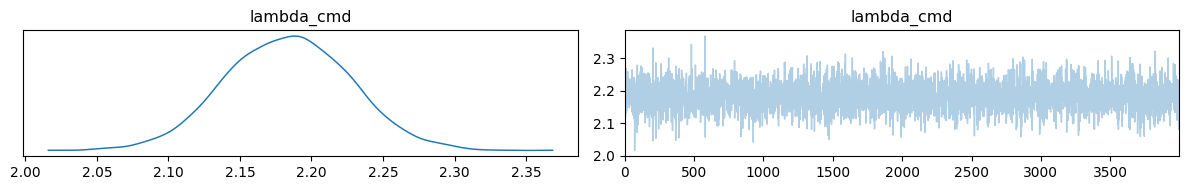

Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


Diagnósticos para parámetros globales del Modelo 2:


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda_cmd,2.183,0.044,2.098,2.268,0.001,0.001,3698.0,3186.0,NaN
weights[0],0.000,0.000,0.000,0.001,0.000,0.000,4607.0,2335.0,NaN
weights[1],0.000,0.000,0.000,0.001,0.000,0.000,4690.0,2250.0,NaN
weights[2],0.000,0.000,0.000,0.001,0.000,0.000,5786.0,2264.0,NaN
weights[3],0.000,0.000,0.000,0.001,0.000,0.000,4765.0,1914.0,NaN
weights[4],0.000,0.000,0.000,0.001,0.000,0.000,4990.0,2052.0,NaN
weights[5],0.000,0.000,0.000,0.001,0.000,0.000,3978.0,1599.0,NaN
weights[6],0.000,0.000,0.000,0.001,0.000,0.000,4609.0,2075.0,NaN
weights[7],0.000,0.000,0.000,0.001,0.000,0.000,3637.0,1753.0,NaN
weights[8],0.000,0.000,0.000,0.001,0.000,0.000,5314.0,2197.0,NaN


In [ ]:
# 2. Diagnóstico de Convergencia para lambda_cmd (Modelo 2)
az.plot_trace(idata_nuts2, var_names=["lambda_cmd"])
plt.tight_layout()
plt.show()

# 3. Resumen de diagnósticos (R-hat y ESS)
summary = az.summary(idata_nuts2, var_names=["lambda_cmd", "weights"], hdi_prob=0.95)
print("Diagnósticos para parámetros globales del Modelo 2:")
display(summary.head(10))

### Comparación Final de Residuos
Graficamos el error relativo $(d_{est} - d_{true}) / d_{true}$ para ver el comportamiento del sesgo en función de la distancia real.

In [ ]:
def get_median_dist(idata):
    return idata.posterior["distance_pc"].median(dim=["chain", "draw"]).values

dists = {
    "Modelo 0 (Solo Par)": get_median_dist(idata_nuts0),
    "Modelo 1 (CMD)": get_median_dist(idata_nuts1),
    "Modelo 2 (CMD+Lambda)": get_median_dist(idata_nuts2)
}

plt.figure(figsize=(10, 6))
for name, d_median in dists.items():
    residual_rel = (d_median - true_dist_nuts) / true_dist_nuts
    sns.scatterplot(x=true_dist_nuts, y=residual_rel, alpha=0.2, s=15, label=name)

plt.axhline(0, color="black", linestyle="--")
plt.ylim(-1, 2)
plt.xlabel("Distancia Real (pc)")
plt.ylabel("Error Relativo (Est - Real) / Real")
plt.title("Comparación de Sesgos: NUTS")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()